Проект сегментация покупателей по признакам. ниже импортируем библиотечки/ В данной работе со всего сета данных будем брать только 1000 так как так будет быстрее грузить ноут и вообще все будет работать лучше так что да вот так вот. 

In [2]:
import pandas as pd
import datetime as dt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [3]:
#далее загружаем данные
all_data_path='C:/Users/sea/Desktop/---/customersegmentation/data/data.csv'
all_data=pd.read_csv(all_data_path, encoding='latin1')
df=all_data

далее проведем первичный анализ данных

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


после проведенного анализа видно,что в данных 541909 строк и 8 колонок. данные содержат информацию о транзакциях магазина: номерсчета, код товара, описание, количество, дата, цена, ID клиента и страна. В данных есть отрицательные значения в Quantity - это возвраты в магазин (от них надо очистить чтобы праивльно произвести сегментацию) 

In [5]:
df=df.drop_duplicates()
df=df.dropna()
df=df[df['Quantity']>=0]
df=df[df['UnitPrice']>0]
df=df[df['CustomerID'].notna()]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    392692 non-null  object 
 1   StockCode    392692 non-null  object 
 2   Description  392692 non-null  object 
 3   Quantity     392692 non-null  int64  
 4   InvoiceDate  392692 non-null  object 
 5   UnitPrice    392692 non-null  float64
 6   CustomerID   392692 non-null  float64
 7   Country      392692 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.0+ MB


после очистки данных от возвратов, пустых значений, повторяющихся данных, а также удалила данные с пустым ID в итоге осталось 392692 строк с которыми мы будем работать.

In [6]:
df['TotalPrice']=df['Quantity']*df['UnitPrice']
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'], format='%m/%d/%Y %H:%M')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  float64       
 7   Country      392692 non-null  object        
 8   TotalPrice   392692 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.0+ MB


выше мы создали колонку TotalPrice, которая равна произведению Quantity*UnitPrice. С помозью данной колонки мы можем увидеть сколько потратил каждый клиент. Также мы преобразовали дату, с помощью этого мы теперь можем найти дату последней покупки каждого клиента, посчитать разницу между датами покупок, а также узнать сколько дней прошло с послежней покупки.

RFM-анализ:

In [7]:
data_rfm=max(df['InvoiceDate'])
rfm=df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (data_rfm-x.max()).days,
    'InvoiceNo': 'nunique', #считаем кол-во уникальных чеков
    'TotalPrice': 'sum'
}).rename(columns={
    'InvoiceDate': 'Recenty',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
})
print(rfm.head())
print(rfm.info())
print(rfm.describe())

            Recenty  Frequency  Monetary
CustomerID                              
12346.0         325          1  77183.60
12347.0           1          7   4310.00
12348.0          74          4   1797.24
12349.0          18          1   1757.55
12350.0         309          1    334.40
<class 'pandas.core.frame.DataFrame'>
Index: 4338 entries, 12346.0 to 18287.0
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Recenty    4338 non-null   int64  
 1   Frequency  4338 non-null   int64  
 2   Monetary   4338 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 135.6 KB
None
           Recenty    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     91.536422     4.272015    2048.688081
std     100.014169     7.697998    8985.230220
min       0.000000     1.000000       3.750000
25%      17.000000     1.000000     306.482500
50%      50.000000     2.000000     668.570000
75%     141.00000

после проведеня RFM-анализа у нас 3 колонки: Recenty - количество дней с полседней покупки (в данном фрагменте данных у всех 0, поскольку мы брали из начала датасета), Frequency - количество покупок/уникальных, Monetary - общая сумма потраченнных денег. в хоче проведения анализа из 392692 очищенных транзакций у нас осталось всего 4338 строк - это значит, что всего 4338 человек совершили 392692 транзакций (без учета возвратов). Из статистики представленной с помощью функции describe() можно заметить, что минимальное количество покупок в данном датасете - 1, максимальное количество покупок - 209, минимальная сумма затрат - 3.75, максимальная сумма затрат - 280206.02, минимальная разница между покупками - 0 дней, максимальная - 373 дня. 

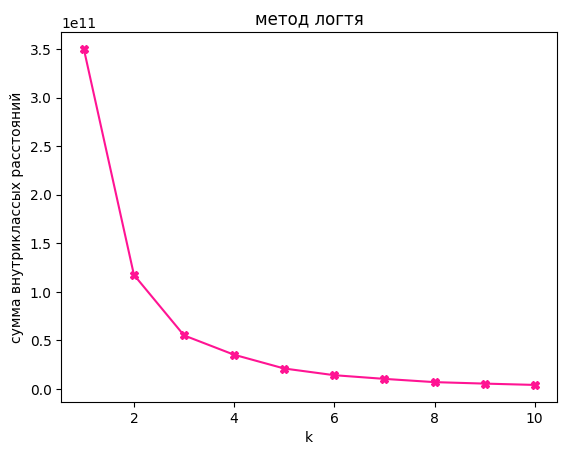

In [10]:
#масштабирование
scaler=StandardScaler()
df_scaled=scaler.fit_transform(rfm)
#используем метод логтя
z=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm)
    z.append(kmeans.inertia_)
plt.plot(range(1,11), z, marker='X', color='deeppink')
plt.title("метод логтя")
plt.ylabel("сумма внутриклассых расстояний")
plt.xlabel("k")
plt.show()

мы произвели масштабирование поскольку в наших данных есть признаки с обльшим разбросом и они будут доминировать, далее с помощью метода логтя нашли к=3. на графике можно визуально увидеть точку к - это место где кривая перестает резко падать.

In [11]:
#кластеризация с помозью kmeans
kmeans=KMeans(n_clusters=3, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(df_scaled)
#добавление меток кластеров к исх дан
rfm['Cluster'] = clusters
print(rfm)
print(rfm['Cluster'].value_counts(normalize=True) * 100)#в процентах кол-во людей

            Recenty  Frequency  Monetary  Cluster
CustomerID                                       
12346.0         325          1  77183.60        1
12347.0           1          7   4310.00        0
12348.0          74          4   1797.24        0
12349.0          18          1   1757.55        0
12350.0         309          1    334.40        1
...             ...        ...       ...      ...
18280.0         277          1    180.60        1
18281.0         180          1     80.82        1
18282.0           7          2    178.05        0
18283.0           3         16   2045.53        0
18287.0          42          3   1837.28        0

[4338 rows x 4 columns]
Cluster
0    74.481328
1    25.195943
2     0.322729
Name: proportion, dtype: float64


можно увидеть, что у нас люди разбились на группы от 0 до 2. также втдно, что 74,5% это люди из 0 группы, 25% из 1 и всего лишь 0,3% из 2 группы.

In [ ]:
cluster_stats = rfm.groupby('Cluster')[['Recenty', 'Frequency', 'Monetary']].mean()
print("среднее значение по группам:")
print(cluster_stats.round(2))
print(rfm['Cluster'].value_counts())#кол-во людей в каждой группе
min_date = df['InvoiceDate'].min()
max_date = df['InvoiceDate'].max()
days = (max_date - min_date).days
print(f"период данных: с {min_date} по {max_date}")
print(f"всего дней: {days}")

среднее значение по группам:
         Recenty  Frequency   Monetary
Cluster                               
0          39.98       4.85    2005.83
1         245.02       1.58     629.36
2           6.14      80.21  122748.79
Cluster
0    3231
1    1093
2      14
Name: count, dtype: int64
период данных: с 2010-12-01 08:26:00 по 2011-12-09 12:50:00
всего дней: 373


глядя на среднее значение по группам, можно сделать вывод, что группа под номером 0 - это наши частые/постоянные покупатели, которые в среднем покупают 5 товаров на 2005,83. Рекомендации к данному типу клентов: ввести программу лояльности, бонусы за повторные покупки, email-рассылки. группа под номером 1 - это редкие покупатели, которые в среднем покупают 1-2 раза за период, а также мало тратят 629,36. Рекомендации: ввести пресонализированные предложения, напоминания, акции для новых покупателей, чтобы вернуть их в магазин. группа под номером 2 - состоит все из 14 человек, котрые довольно-таки часто покупают много и тратят большие суммы. Рекомендации: добавить персонального менеджера, дял комфорта vip клиентов, эксклюзивные предложения, бесплатная доставка, информацию о каких-либо новинках сначала отправлять, индивидуальные предложения.